<a href="https://colab.research.google.com/github/arisusilo/DataScience_250401020117_AriSusilo/blob/main/Pertemuan12_Ari_Susilo_250401020117.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PERTEMUAN KE 12**

**Nama** **=** **Ari Susilo**

**Nim** **=** **250401020117**

**Kelas** **=** **IF405**

**Langkah 1: Generate & Eksplorasi Dataset Transaksi**

In [11]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append([str(x) for x in np.random.choice(produk, n_item, replace=False)])

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Contoh transaksi:', transaksi[:3])
print('Jumlah transaksi:', len(transaksi))

Contoh transaksi: [['Keju', 'Roti', 'Mentega', 'Kopi', 'Selai'], ['Roti', 'Kopi', 'Teh', 'Selai', 'Mentega'], ['Kopi', 'Susu', 'Teh']]
Jumlah transaksi: 50


Eksplorasi cepat: frekuensi kemunculan tiap produk di seluruh transaksi.

Selai      26
Teh        23
Mentega    21
Telur      18
Keju       17
Roti       16
Kopi       16
Susu       16
Gula       16
Sereal      9
dtype: int64


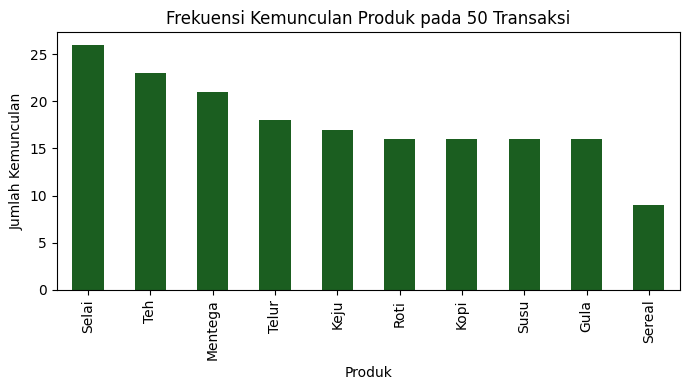

In [2]:
from collections import Counter
flat = [item for t in transaksi for item in t]
freq_count = Counter(flat)
freq_series = pd.Series(freq_count).sort_values(ascending=False)
print(freq_series)

plt.figure(figsize=(7,4))
freq_series.plot(kind='bar', color='#1B5E20')
plt.title('Frekuensi Kemunculan Produk pada 50 Transaksi')
plt.ylabel('Jumlah Kemunculan')
plt.xlabel('Produk')
plt.tight_layout()
plt.show()

**Observasi:** Selai dan Roti sama-sama muncul dengan frekuensi tinggi karena pola cross-sell yang sengaja disuntikkan di Langkah 1 — sesuai dugaan, ini akan terlihat lagi di tahap association rules.

**Langkah 2: One-Hot Encoding Transaksi**

In [3]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_ary, columns=te.columns_)
print(df.shape)
df.head()

(50, 10)


,Gula,Keju,Kopi,Mentega,Roti,Selai,Sereal,Susu,Teh,Telur
0,False,True,True,True,True,True,False,False,False,False
1,False,False,True,True,True,True,False,False,True,False
2,False,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,True,False,False,True,True
4,True,True,False,True,False,False,False,True,False,False


**Langkah 3: Cari Frequent Itemset dengan Apriori**

In [13]:
from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f'min_support={ms}: {len(freq)} itemset ditemukan')

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan


In [12]:
freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)
freq_items.head(10)

,support,itemsets
5,0.52,(Selai)
8,0.46,(Teh)
3,0.42,(Mentega)
9,0.36,(Telur)
1,0.34,(Keju)
0,0.32,(Gula)
2,0.32,(Kopi)
4,0.32,(Roti)
7,0.32,(Susu)
36,0.24,"(Selai, Teh)"


**Langkah 4: Bentuk & Saring Aturan Asosiasi**

In [14]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False)
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

,antecedents,consequents,support,confidence,lift
9,"(Teh, Keju)",(Telur),0.12,0.857143,2.380952
14,"(Selai, Mentega)",(Kopi),0.10,0.625000,1.953125
12,"(Gula, Roti)",(Selai),0.10,1.000000,1.923077
7,(Sereal),(Mentega),0.14,0.777778,1.851852
8,"(Teh, Telur)",(Keju),0.12,0.600000,1.764706
13,"(Selai, Kopi)",(Mentega),0.10,0.714286,1.700680
10,"(Telur, Keju)",(Teh),0.12,0.750000,1.630435
11,"(Selai, Gula)",(Roti),0.10,0.500000,1.562500
15,"(Kopi, Mentega)",(Selai),0.10,0.714286,1.373626
1,(Roti),(Selai),0.22,0.687500,1.322115


**Interpretasi:**
- Aturan dengan Lift tertinggi menunjukkan pasangan produk yang paling kuat berkorelasi positif — dibeli bersama jauh lebih sering dibanding jika keduanya independen.
- Aturan `Roti → Selai` juga muncul dalam daftar dengan Lift > 1, sesuai dengan pola yang sengaja disuntikkan pada Langkah 1, dan **masuk akal secara bisnis** (roti dan selai memang lazim dibeli bersamaan).
- Aturan-aturan lain dengan Lift tinggi (mis. kombinasi Teh, Keju, Telur) kemungkinan besar muncul karena kebetulan statistik pada dataset sintetis berukuran kecil (50 transaksi) — dalam praktik nyata, aturan seperti ini perlu divalidasi dengan data yang lebih besar sebelum dijadikan keputusan bisnis (mis. penataan rak).

**Langkah 5: Rekomender Sederhana dengan Content-Based Filtering**

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    'produk': produk,
    'kategori': ['Bakery','Bakery','Dairy','Bakery','Dairy',
                 'Dairy','Minuman','Bumbu','Minuman','Dairy']
})
fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]
    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]
    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

print('Mirip dengan Roti:', rekomendasi_serupa('Roti'))

Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']


**Langkah 6: Bandingkan Kedua Pendekatan**

In [16]:
produk_target = 'Roti'

# Dari association rules: cari consequents dari aturan yang antecedent-nya mengandung produk_target
rules_terkait = rules[rules['antecedents'].apply(lambda x: produk_target in x)]
print('Rekomendasi dari Association Rules:')
print(rules_terkait[['consequents', 'lift']].head())

print()
print('Rekomendasi dari Content-Based:', rekomendasi_serupa(produk_target))

Rekomendasi dari Association Rules:
   consequents      lift
12     (Selai)  1.923077
1      (Selai)  1.322115

Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu']


## Kesimpulan
- Algoritma Apriori berhasil menemukan pola pembelian bersama dalam data transaksi sintetis, termasuk pola yang sengaja disuntikkan (Roti → Selai), dan disaring menggunakan min_support, min_confidence,serta lift > 1 agar aturan yang dihasilkan benar-benar bermakna secara statistik.
- Content-Based Filtering, dengan cosine similarity atas atribut kategori, mampu memberikan rekomendasi tanpa membutuhkan riwayat transaksi pengguna lain — cocok untuk skenario cold start.
- Membandingkan kedua pendekatan menunjukkan bahwa mereka menangkap sinyal yang berbeda (perilaku vs atribut), sehingga pendekatan **Hybrid** menjadi pilihan yang paling robust untuk sistem rekomendasi di dunia nyata.